In [70]:
# Load Libraries
from sklearn.linear_model import LogisticRegression

# Other necessary packages
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.pipeline import make_pipeline           # combining classifier steps
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.model_selection import train_test_split

# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.metrics import make_scorer

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
###
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn modules
import sklearn

#Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,classification_report, ConfusionMatrixDisplay
from sklearn.metrics import  RocCurveDisplay, roc_auc_score, accuracy_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC         # SVM
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold

#Statistical libraries
from scipy.stats import chi2_contingency
#Custom function to computer the within cluster variance (will be used as custom scoring method for spectral clustering)
def compute_wcv(labels, X):
    wcv = 0
    for cluster in np.unique(labels):
        X_cluster = X[labels==cluster]
        centroid = np.mean(X_cluster,axis=0)
        wcv_cluster = ((X_cluster - centroid)**2).sum().sum()
        wcv += wcv_cluster
    return wcv

def spectral_scorer_wcv(estimator, X, y=None):
    labels = estimator.fit_predict(X)
    wcv = compute_wcv(labels, X)
    return -wcv

def spectral_scorer_sil(estimator, X, y=None):
    labels = estimator.fit_predict(X)
    score =  silhouette_score(X,labels,metric="cosine")
    return -score

from sklearn.inspection import DecisionBoundaryDisplay
import sklearn.preprocessing

# Visualize the decision boundary and margin
# For D=2 inputs and binary classification
def plot_margin(model, X, y, figsize=(8,7)):
    
    fig, ax = plt.subplots(1,1,figsize=figsize)

    # Scatter plot of the inputs colored by class 
    ax.scatter(X[:,0], X[:,1], c=y, s=30)
    
    # Show decsision boundary
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        plot_method="contour",
        colors="k",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        ax=ax,
    )

    # Highlight support vectors
    # If pipeline with StandardScalar, inverse transform the support vectors
    if (isinstance(model, sklearn.pipeline.Pipeline)):
        if (isinstance(model[0], sklearn.preprocessing.StandardScaler)):
            support_vectors = model[0].inverse_transform(model[-1].support_vectors_)
        else:
            support_vectors = model[-1].support_vectors_
    else:
        support_vectors = model.support_vectors_
    ax.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=100,
        linewidth=1,
        facecolors="none",
        edgecolors="k",
    )
    plt.show()

In [2]:
#want to do clustering on snr using the features the describe the projection type of the neurons,
#then we want to see if those clusters are reflected by the "proj" labels.

# load data
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

ec_snr_data.head()


,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRd_length,STRv_endpoint,STRv_length,x,y,z,comment,injection,proj,count
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,35586.500280,79,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,8835.140534,7,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,57612.283980,71,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,30481.705940,16,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,26718.999420,81,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3


In [3]:
length_cols = []

for col in ec_snr_data.columns:
    if col.endswith("_length"):
        length_cols.append(col)

In [5]:
print(length_cols)

['FRP_length', 'SS_length', 'VIS_length', 'VISpor_length', 'RSP_length', 'PTLp_length', 'ORB_length', 'MO_length', 'AUD_length', 'ACA_length', 'PL_length', 'ILA_length', 'VISC_length', 'AI_length', 'GU_length', 'TEa_length', 'PERI_length', 'ECT_length', 'OLF_length', 'PAR_length', 'POST_length', 'PRE_length', 'SUB_length', 'HIP_length', 'CLA_length', 'EP_length', 'AMY_length', 'STRd_length', 'STRv_length']


In [12]:
neocortical_regions = [
    "FRP_length",
    "PL_length",
    "ILA_length",
    "ORB_length",
    "MO_length",
    "ACA_length",
    "SS_length",
    "VIS_length",
    "VISpor_length",
    "RSP_length",
    "PTLp_length"
]

non_neocortical_regions = [col for col in length_cols if col not in neocortical_regions]

In [13]:
non_neocortical_regions


[
    'AUD_length',
    'VISC_length',
    'AI_length',
    'GU_length',
    'TEa_length',
    'PERI_length',
    'ECT_length',
    'OLF_length',
    'PAR_length',
    'POST_length',
    'PRE_length',
    'SUB_length',
    'HIP_length',
    'CLA_length',
    'EP_length',
    'AMY_length',
    'STRd_length',
    'STRv_length'
]

In [14]:
ec_snr_data["neocortical_length"] = ec_snr_data[neocortical_regions].sum(axis=1)
ec_snr_data["non_neocortical_length"] = ec_snr_data[non_neocortical_regions].sum(axis=1)

In [15]:
ec_snr_data.head()

,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRv_length,x,y,z,comment,injection,proj,count,neocortical_length,non_neocortical_length
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6,44296.421904,190555.838451
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5,23229.342306,62003.429391
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8,147832.177244,184751.046174
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6,35594.429616,64106.606975
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3,33498.517901,186535.250857


Text(0.5, 1.0, 'Distribution of neocortical length among neurons')

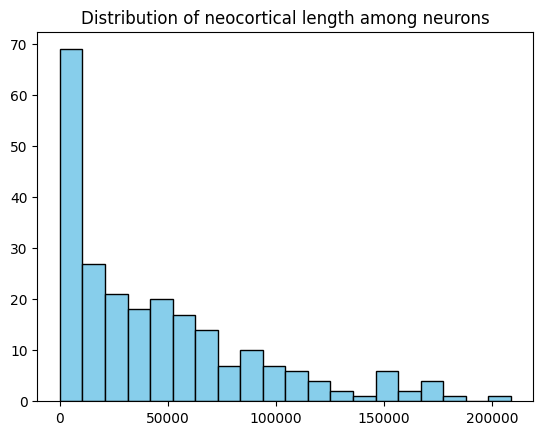

In [ ]:
#understand distribution of neocortical length and non neocortical length 
fig, ax = plt.subplots(1,1)
ax.hist(ec_snr_data["neocortical_length"], color="skyblue", edgecolor="black", bins=20)
ax.set_title("Distribution of neocortical length among neurons")

In [50]:
# compute 90th percentile for each length variable
threshold = ec_snr_data["neocortical_length"].quantile(0.80)

ec_snr_data["neocortical_label"] = np.where(
    ec_snr_data["neocortical_length"] >= threshold,
    "neocortical",
    "non_neocortical"
)

ec_snr_data["neocortical_label"].value_counts()



neocortical_label
non_neocortical    189
neocortical         48
Name: count, dtype: int64

Want to train a spatial classifier: predict neocortical/non neocortical from coords x,y,z

In [51]:
#Base model: multiclass logistic regression
to_drop = []
for elem in ec_snr_data.columns:
    if elem not in ["x","y","z","neocortical_label"]:
        to_drop.append(elem)

X = ec_snr_data.drop(to_drop, axis=1)
print(X["neocortical_label"].value_counts()) #Fairly balanced classes

# Feature matrix and response vector
X, y = X.drop(["neocortical_label"], axis=1), X["neocortical_label"]

#Encode target
y = LabelEncoder().fit_transform(y)

# Split into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=True, stratify=y) 

neocortical_label
non_neocortical    189
neocortical         48
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.19      0.67      0.30        15
           1       0.75      0.26      0.39        57

    accuracy                           0.35        72
   macro avg       0.47      0.46      0.34        72
weighted avg       0.63      0.35      0.37        72



c:\Users\ricca\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


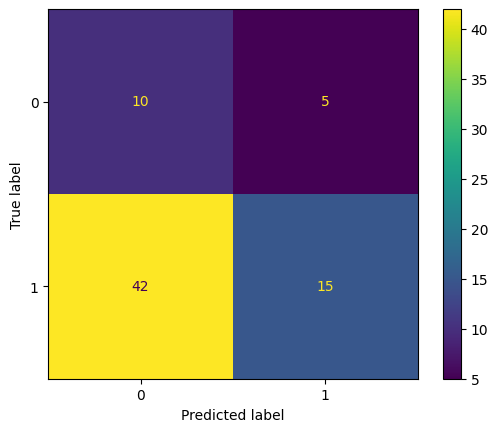

In [62]:

# !pip install imblearn
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

log_pipe_multi = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        random_state=0,
        penalty="l2",
        class_weight="balanced"
    )
)

log_pipe_multi.fit(X_train, y_train)

y_pred = log_pipe_multi.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    log_pipe_multi,
    X_test,
    y_test
)

In [53]:
# Compute and print the classification report for the model with no penatly
from sklearn.metrics import classification_report

print(classification_report(y_test, 
                            log_pipe_multi.predict(X_test), 
                            target_names = ['0','1']))

              precision    recall  f1-score   support

           0       0.19      0.67      0.30        15
           1       0.75      0.26      0.39        57

    accuracy                           0.35        72
   macro avg       0.47      0.46      0.34        72
weighted avg       0.63      0.35      0.37        72



c:\Users\ricca\miniconda3\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


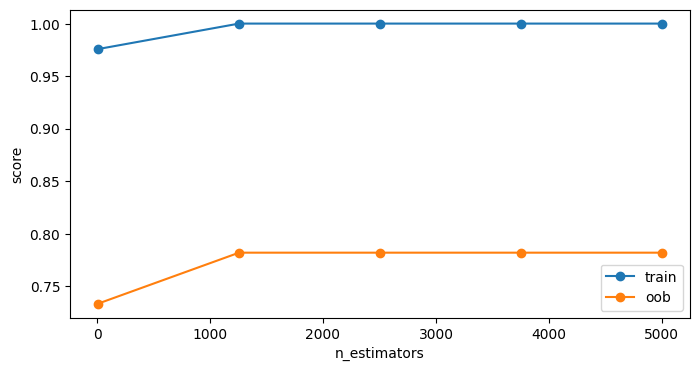

In [54]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define a range of n_estimators to test
n_est = np.linspace(10, 5000, 5, dtype=int)

#Initialize lists to store training and OOB scores
train_scores = []
oob_scores = []

#Fit a random forest model for each value of n_estimators and store the training and OOB scores
for n in n_est:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        max_features="sqrt",
        random_state=0,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    oob_scores.append(rf.oob_score_)

#Plot the training and OOB scores as a function of n_estimators
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_xlabel("n_estimators")
ax.set_ylabel("score")
ax.plot(n_est, train_scores, marker="o", label="train")
ax.plot(n_est, oob_scores, marker="o", label="oob")
ax.legend()
plt.show()

In [65]:
# Pipeline: preprocessing + random forest
rf_pipe = make_pipeline(
    RandomForestClassifier(
        random_state=0,
        n_jobs=-1,
    )
)

# param_grid = {
#     "randomforestclassifier__n_estimators": [300, 500, 1000, 1500],
#     "randomforestclassifier__max_depth": [2, 3, 4, 5],
#     "randomforestclassifier__min_samples_leaf": [1, 3, 5, 10],
#     "randomforestclassifier__max_features": ["sqrt", None],
#     "randomforestclassifier__class_weight": [
#     None,
#     "balanced",
#     {0: 1, 1: 1, 2: 1.05},
#     {0: 1, 1: 1, 2: 1.1},
#     {0: 1, 1: 1, 2: 1.15},
#     {0: 1, 1: 1, 2: 1.2},
#     {0: 1, 1: 1, 2: 1.25},
#     {0: 1, 1: 1, 2: 1.3},
#     {0: 1, 1: 1, 2: 1.35},
#     {0: 1, 1: 1, 2: 1.4},
# ]
# }

param_grid = {
    "randomforestclassifier__n_estimators": [1500],
    "randomforestclassifier__max_depth": [2, 3, 4, 5],
    "randomforestclassifier__min_samples_leaf": [1, 3, 5, 10],
    "randomforestclassifier__max_features": ["sqrt", None],
    "randomforestclassifier__class_weight": [
    None,
    "balanced",
    {1: 1, 0: 1.1},
    {1: 1, 0: 1.2},
    {1: 1, 0: 1.3},
    {1: 1, 0: 1.4},
]
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grid search
rf_gs = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=["accuracy", "balanced_accuracy", "f1_macro", "precision_macro", "recall_macro"],
    cv=cv,
    refit="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
rf_gs.fit(X_train, y_train)

# Best tuned pipeline
best_rf_pipe = rf_gs.best_estimator_

print("Best RF parameters:")
print(rf_gs.best_params_)

print("Best CV f1_macro:")
print(round(rf_gs.best_score_, 4))

# Test set evaluation
acc_rf = best_rf_pipe.score(X_test, y_test)
print("Random forest test set accuracy:", round(acc_rf, 4))

#Compute AUC on the test set
y_proba_rf = best_rf_pipe.predict_proba(X_test)

auc_rf = roc_auc_score(
    y_test,
    y_proba_rf[:, 1], # multi_class="ovr"
    average="macro"
)

print(f"Random forest macro AUC: {auc_rf:.4f}")

#Print classification report
print(classification_report(y_test, best_rf_pipe.predict(X_test), 
                            target_names=["0", "1"]))

# Feature importances
best_rf_model = best_rf_pipe[-1]

# Get the names of the transformed features after preprocessing
feature_names = X_train.columns

# Build a DataFrame of feature importances
rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importance_df.head(20))

Best RF parameters:
{'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__max_features': None, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__n_estimators': 1500}
Best CV f1_macro:
0.6653
Random forest test set accuracy: 0.6111
Random forest macro AUC: 0.5380
              precision    recall  f1-score   support

           0       0.16      0.20      0.18        15
           1       0.77      0.72      0.75        57

    accuracy                           0.61        72
   macro avg       0.47      0.46      0.46        72
weighted avg       0.65      0.61      0.63        72

  feature  importance
0       x    0.407505
2       z    0.347262
1       y    0.245233


              precision    recall  f1-score   support

           0       0.16      0.20      0.18        15
           1       0.77      0.72      0.75        57

    accuracy                           0.61        72
   macro avg       0.47      0.46      0.46        72
weighted avg       0.65      0.61      0.63        72



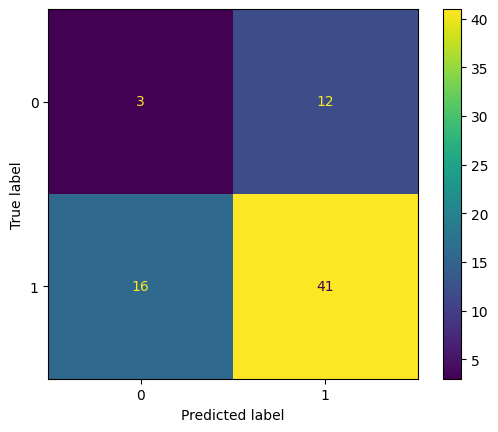

In [67]:
ConfusionMatrixDisplay.from_estimator(best_rf_pipe, X_test, y_test)

print(classification_report(y_test, best_rf_pipe.predict(X_test), 
                            target_names=["0", "1"]))


Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best params:
{'randomforestclassifier__class_weight': None, 'randomforestclassifier__max_depth': 5, 'randomforestclassifier__max_features': None, 'randomforestclassifier__min_samples_leaf': 10, 'randomforestclassifier__n_estimators': 1000, 'randomoversampler__sampling_strategy': 0.7}
              precision    recall  f1-score   support

           0       0.20      0.27      0.23        15
           1       0.79      0.72      0.75        57

    accuracy                           0.62        72
   macro avg       0.49      0.49      0.49        72
weighted avg       0.67      0.62      0.64        72

Balanced accuracy: 0.49298245614035086
Macro F1: 0.49043250327654


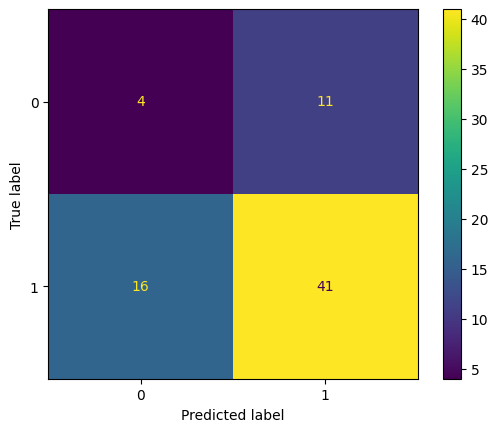

In [68]:
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score

rf_pipe_ros = make_pipeline(
    RandomOverSampler(random_state=0),
    RandomForestClassifier(
        random_state=0,
        n_jobs=-1
    )
)

param_grid = {
    "randomoversampler__sampling_strategy": [0.4, 0.5, 0.7, 1.0],
    "randomforestclassifier__n_estimators": [1000, 1500],
    "randomforestclassifier__max_depth": [3, 4, 5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 3, 5, 10],
    "randomforestclassifier__max_features": ["sqrt", None],
    "randomforestclassifier__class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

rf_gs_ros = GridSearchCV(
    estimator=rf_pipe_ros,
    param_grid=param_grid,
    scoring=["balanced_accuracy", "f1_macro", "recall_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

rf_gs_ros.fit(X_train, y_train)

best_rf_ros = rf_gs_ros.best_estimator_

y_pred = best_rf_ros.predict(X_test)

print("Best params:")
print(rf_gs_ros.best_params_)

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

ConfusionMatrixDisplay.from_estimator(best_rf_ros, X_test, y_test)

Spatial coordinates alone are insufficient to robustly predict neocortical projection labels.

In [71]:
# SVM with rbf kernel
svm_pipe = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True)) #control observed trade off between class 1 and 2

# Grid search over C and the degree of the polynomial
# gamma = np.linspace(0.001, 3, 50)
gamma = np.logspace(-3, 1, 9)
C = np.linspace(0.1, 10, 100)
# class_weight_options = [
#     None,
#     "balanced",
#     {0: 1, 1: 1, 2: 1.05},
#     {0: 1, 1: 1, 2: 1.1},
#     {0: 1, 1: 1, 2: 1.15},
#     {0: 1, 1: 1, 2: 1.2},
#     {0: 1, 1: 1, 2: 1.25},
#     {0: 1, 1: 1, 2: 1.3},
#     {0: 1, 1: 1, 2: 1.35},
# ]

class_weight_options = [
    None,
    "balanced",
    {0: 1, 1: 1.1},
    {0: 1, 1: 1.2},
    {0: 1, 1: 1.3},
    {0: 1, 1: 1.4},
    {0: 1.1, 1: 1},
    {0: 1.2, 1: 1}, 
    {0: 1.3, 1: 1}, 
    {0: 1.4, 1: 1},
]

cv2 = GridSearchCV(
    svm_pipe,
    param_grid={
        "svc__C": C,
        "svc__gamma": gamma,
        "svc__class_weight": class_weight_options
    },
    scoring=["accuracy", "balanced_accuracy", "f1_macro", "precision_macro", "recall_macro"],
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
    refit="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

# Fit and tune the model
cv2.fit(X_train, y_train)

best_svm_pipe = cv2.best_estimator_

# Get the best model parameters and the accuracy of the model
print("Params: ", cv2.best_params_)
print("Avg Accuracy: ", cv2.best_score_)

Params:  {'svc__C': np.float64(1.9000000000000001), 'svc__class_weight': 'balanced', 'svc__gamma': np.float64(10.0)}
Avg Accuracy:  0.6968125363352888


Best CV f1_macro:
0.6968
SVC rbf macro AUC: 0.4912


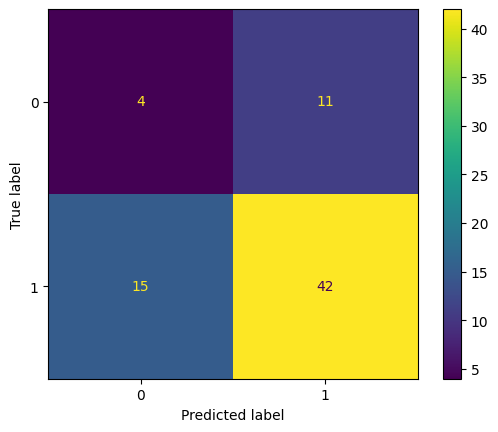

In [72]:
print("Best CV f1_macro:")
print(round(cv2.best_score_, 4))

#Compute AUC on the test set
y_proba_svm = best_svm_pipe.predict_proba(X_test)

auc_svm = roc_auc_score(
    y_test,
    y_proba_svm[:,1],  # multi_class="ovr"
    average="macro"
)

print(f"SVC rbf macro AUC: {auc_svm:.4f}")

#plot 
ConfusionMatrixDisplay.from_estimator(cv2.best_estimator_, X_test, y_test)